In [2]:
!pip install tensorflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.



   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 238.4 kB/s eta 0:24:31
   ---------------------------------------- 0.5/351.2 MB 238.4 kB/s

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
## visualization

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

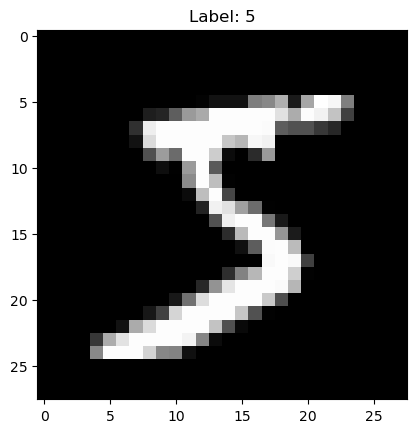

In [5]:
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [6]:
## normalization

x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
## Data Shape Confirm + Flatten Understanding

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


In [8]:
## making image ANN-friendly

x_train_flat = x_train.reshape(60000, 28*28)
x_test_flat = x_test.reshape(10000, 28*28)

In [9]:
print("x_train_flat:" , x_train_flat.shape)
print("x_test_flat:" , x_test_flat.shape)

x_train_flat: (60000, 784)
x_test_flat: (10000, 784)


In [10]:
## ab each image 1D array meh convert hu chuki hy

NOW ANN Model (Architecture)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [12]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    x_train_flat,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8215 - loss: 0.6850 - val_accuracy: 0.9086 - val_loss: 0.3311
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9089 - loss: 0.3169 - val_accuracy: 0.9222 - val_loss: 0.2697
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9246 - loss: 0.2645 - val_accuracy: 0.9326 - val_loss: 0.2335
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9340 - loss: 0.2311 - val_accuracy: 0.9397 - val_loss: 0.2119
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9412 - loss: 0.2053 - val_accuracy: 0.9449 - val_loss: 0.1936


In [15]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9441 - loss: 0.1940    
Test Loss: 0.19399866461753845
Test Accuracy: 0.944100022315979


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
Predicted: 7
Actual: 7


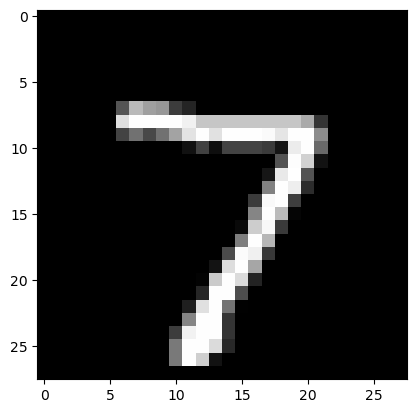

In [18]:
predictions = model.predict(x_test_flat)

import numpy as np

predicted_label = np.argmax(predictions[0])

print("Predicted:", predicted_label)
print("Actual:", y_test[0])

plt.imshow(x_test[0], cmap='gray')
plt.show()

## EVALUATION

In [19]:
import numpy as np

y_pred = model.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


In [20]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

Accuracy: 0.9441
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.92      0.93      1032
           3       0.92      0.95      0.93      1010
           4       0.95      0.94      0.95       982
           5       0.95      0.91      0.93       892
           6       0.93      0.97      0.95       958
           7       0.96      0.93      0.94      1028
           8       0.93      0.92      0.93       974
           9       0.91      0.93      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



# Phase 1 — Activation Comparison

## Experiment 1

In [22]:
##  already done it, in previous cells 

## Experiment 2

In [23]:
model_sigmoid = Sequential()

model_sigmoid.add(Dense(128, activation='sigmoid', input_shape=(784,)))
model_sigmoid.add(Dense(64, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model_sigmoid.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history_sigmoid = model_sigmoid.fit(
    x_train_flat,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3296 - loss: 2.2173 - val_accuracy: 0.5919 - val_loss: 2.0876
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6016 - loss: 1.8482 - val_accuracy: 0.6847 - val_loss: 1.5378
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7098 - loss: 1.2766 - val_accuracy: 0.7614 - val_loss: 1.0354
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7779 - loss: 0.9212 - val_accuracy: 0.8148 - val_loss: 0.7851
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8177 - loss: 0.7352 - val_accuracy: 0.8509 - val_loss: 0.6426


In [26]:
## training done 

In [27]:
# evaluation

test_loss_sigmoid, test_acc_sigmoid = model_sigmoid.evaluate(x_test_flat, y_test)

print("Sigmoid Test Loss:", test_loss_sigmoid)
print("Sigmoid Test Accuracy:", test_acc_sigmoid)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8392 - loss: 0.6530
Sigmoid Test Loss: 0.6529871821403503
Sigmoid Test Accuracy: 0.8392000198364258


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  
Predicted: 7
Actual: 7


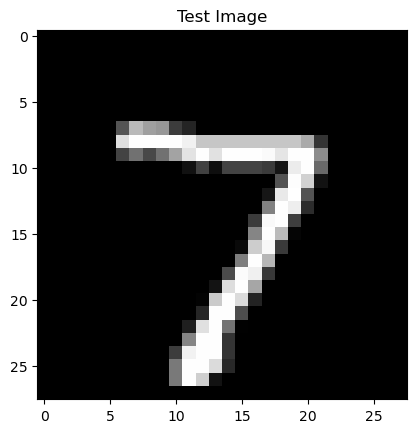

In [29]:
import numpy as np

predictions = model_sigmoid.predict(x_test_flat)

predicted_label = np.argmax(predictions[0])

print("Predicted:", predicted_label)
print("Actual:", y_test[0])

plt.imshow(x_test[0], cmap='gray')
plt.title("Test Image")
plt.show()

In [30]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# predictions ko class labels mein convert karo
y_pred_sigmoid = model_sigmoid.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred_sigmoid, axis=1)

# report print karo
print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
Accuracy: 0.8392
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       980
           1       0.88      0.98      0.93      1135
           2       0.88      0.82      0.85      1032
           3       0.84      0.84      0.84      1010
           4       0.74      0.82      0.78       982
           5       0.78      0.73      0.75       892
           6       0.88      0.91      0.90       958
           7       0.87      0.87      0.87      1028
           8       0.84      0.73      0.78       974
           9       0.76      0.70      0.73      1009

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



## EXPERIMENT 3

In [31]:
model_tanh = Sequential()

model_tanh.add(Dense(128, activation='tanh', input_shape=(784,)))
model_tanh.add(Dense(64, activation='tanh'))
model_tanh.add(Dense(10, activation='softmax'))

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model_tanh.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
history_tanh = model_tanh.fit(
    x_train_flat,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8379 - loss: 0.6468 - val_accuracy: 0.9006 - val_loss: 0.3674
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9030 - loss: 0.3495 - val_accuracy: 0.9157 - val_loss: 0.2995
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9139 - loss: 0.2989 - val_accuracy: 0.9242 - val_loss: 0.2675
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9234 - loss: 0.2683 - val_accuracy: 0.9302 - val_loss: 0.2476
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9289 - loss: 0.2454 - val_accuracy: 0.9349 - val_loss: 0.2283


In [34]:
test_loss_tanh, test_acc_tanh = model_tanh.evaluate(x_test_flat, y_test)

print("Tanh Test Loss:", test_loss_tanh)
print("Tanh Test Accuracy:", test_acc_tanh)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9333 - loss: 0.2297
Tanh Test Loss: 0.22972050309181213
Tanh Test Accuracy: 0.9333000183105469


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  
Predicted: 7
Actual: 7


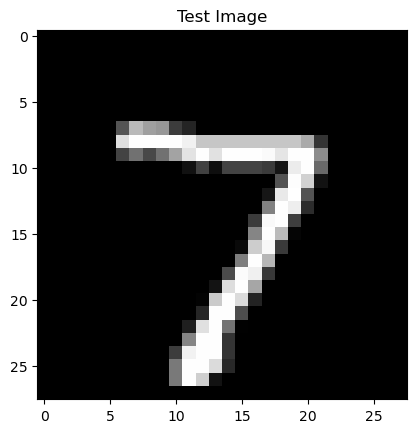

In [36]:
import numpy as np

predictions = model_tanh.predict(x_test_flat)

predicted_label = np.argmax(predictions[0])

print("Predicted:", predicted_label)
print("Actual:", y_test[0])

plt.imshow(x_test[0], cmap='gray')
plt.title("Test Image")
plt.show()

In [35]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

y_pred_tanh = model_tanh.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred_tanh, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   
Accuracy: 0.9333
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.97      0.98      0.97      1135
           2       0.94      0.91      0.93      1032
           3       0.90      0.94      0.92      1010
           4       0.93      0.94      0.93       982
           5       0.93      0.87      0.90       892
           6       0.94      0.96      0.95       958
           7       0.94      0.93      0.93      1028
           8       0.91      0.91      0.91       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [38]:
import matplotlib.pyplot as plt

plt.plot(history_relu.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

NameError: name 'history_relu' is not defined